# Section 4: SIFT

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import math

In [ ]:
img1=cv2.imread('church_002.png',cv2.IMREAD_GRAYSCALE)
img2=cv2.imread('church_003.png',cv2.IMREAD_GRAYSCALE)
if img1 is None or img2 is None:
    raise FileNotFoundError("Please place church_002.png and church_003.png in the working directory.")
img1f=img1.astype(np.float32)/255.0
img2f=img2.astype(np.float32)/255.0
#noting the parameters for further use
s=3
sigma0=0.6
octaves=3
threshold=0.01

## Task 1: Build Pyramid and Detect Keypoints for image 1

In [61]:
def build_gaussian_pyramid(img,s,sigma0,octaves=3):
    pyramid=[]
    k=2**(1.0/s)
    curf=img.astype(np.float32)
    if curf.max()>1.0:
        current=curf/255.0
    else:
        current=curf

    for oct in range(octaves):
        octave_images=[]
        for i in range(s+3):
            sigma=sigma0*(k**i)
            blurred=gaussian_filter(current,sigma)
            octave_images.append(blurred)
        pyramid.append(octave_images)

        base_for_next=octave_images[s]
        h,w=base_for_next.shape
        current=cv2.resize(base_for_next,(w//2,h//2),interpolation=cv2.INTER_LINEAR)

    return pyramid


def compute_dog(pyramid):
    dog_pyramid=[]
    for octave in pyramid:
        dog=[]
        for i in range(len(octave)-1):
            dog.append(octave[i+1]-octave[i])
        dog_pyramid.append(dog)
    return dog_pyramid


def detect_keypoints(dog_pyramid,s,threshold=0.01):
    keypoints=[]
    for oct_idx,dog_oct in enumerate(dog_pyramid):
        for scale_idx in range(1,s+1):
            curr=dog_oct[scale_idx]
            lower=dog_oct[scale_idx-1]
            upper=dog_oct[scale_idx+1]

            h,w=curr.shape
            for i in range(1,h-1):
                for j in range(1,w-1):
                    val=curr[i,j]
                    block_curr=curr[i-1:i+2,j-1:j+2].flatten()
                    block_curr=np.delete(block_curr,4)
                    block_low=lower[i-1:i+2,j-1:j+2].flatten()
                    block_up=upper[i-1:i+2,j-1:j+2].flatten()
                    neighbours=np.concatenate([block_curr,block_low,block_up])

                    if val>0 and val>np.max(neighbours):
                        if abs(val)>=threshold:
                            keypoints.append((oct_idx,scale_idx,j,i,val))
                    elif val<0 and val<np.min(neighbours):
                        if abs(val)>=threshold:
                            keypoints.append((oct_idx,scale_idx,j,i,val))
    return keypoints


pyramid1=build_gaussian_pyramid(img1f,s,sigma0,octaves)
dog_pyramid1=compute_dog(pyramid1)
keypoints_raw1=detect_keypoints(dog_pyramid1,s,threshold)
kps1=[(oct,sc,x,y) for (oct,sc,x,y,val) in keypoints_raw1]
print(f"Detected {len(kps1)} keypoints in image 1.")

Detected 5207 keypoints in image 1.


Visualize Gaussian Pyramid (first 4 scales per octave)

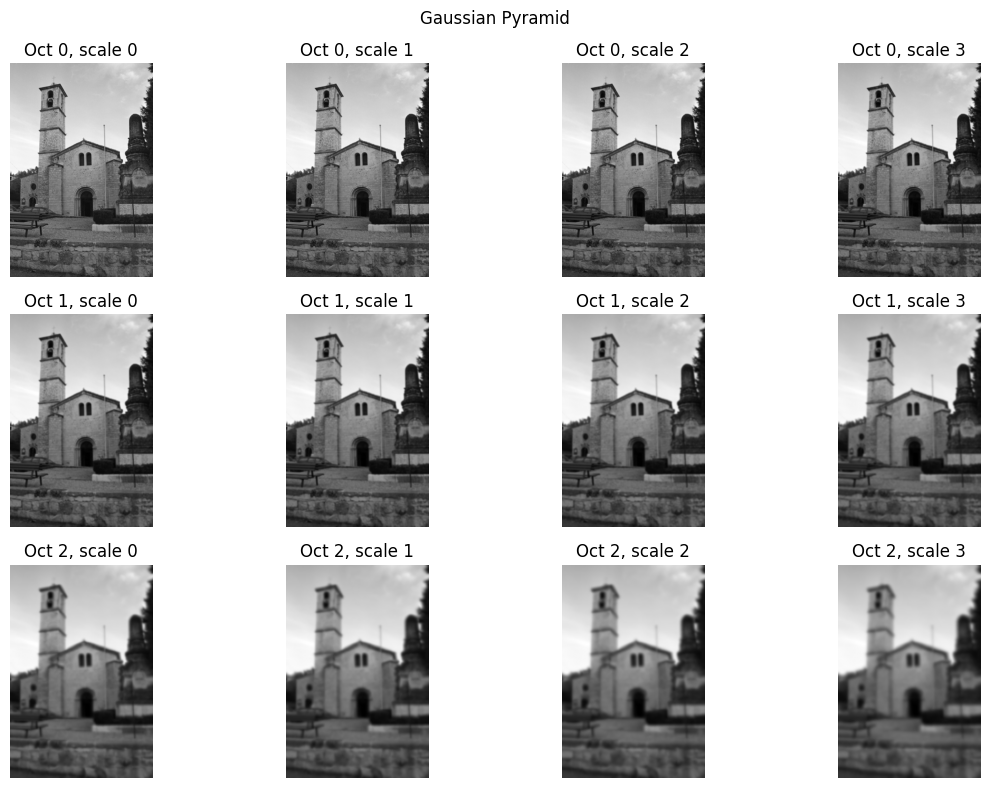

In [62]:
fig,axes=plt.subplots(octaves,4,figsize=(12,8))
for o in range(octaves):
    for i in range(4):
        axes[o,i].imshow(pyramid1[o][i],cmap='gray')
        axes[o,i].set_title(f'Oct {o}, scale {i}')
        axes[o,i].axis('off')
plt.suptitle('Gaussian Pyramid')
plt.tight_layout()
plt.show()

Visualize DoG Pyramid (first 3 DoG images per octave)

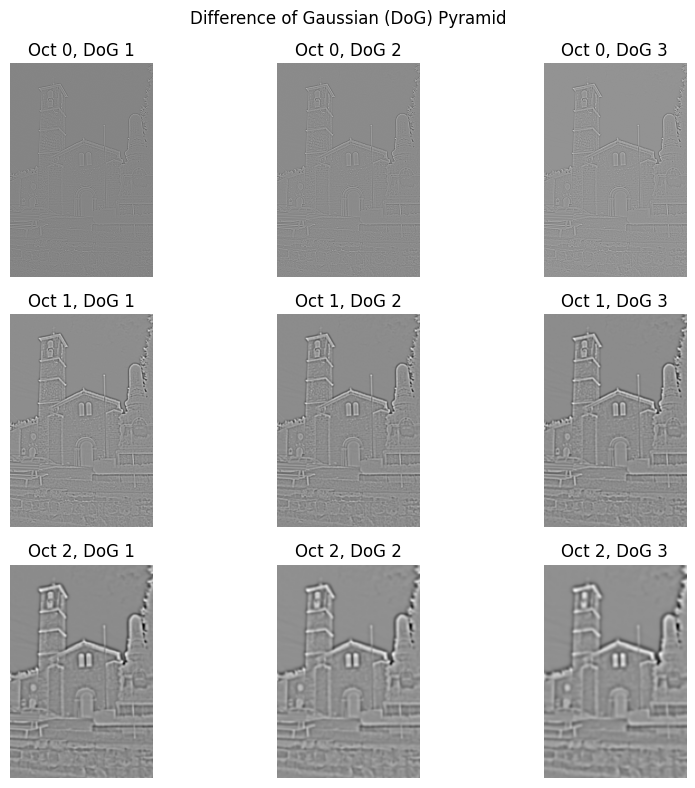

In [63]:
fig,axes=plt.subplots(octaves,3,figsize=(9,8))
for o in range(octaves):
    for i in range(3):
        axes[o,i].imshow(dog_pyramid1[o][i+1],cmap='gray')
        axes[o,i].set_title(f'Oct {o}, DoG {i+1}')
        axes[o,i].axis('off')
plt.suptitle('Difference of Gaussian (DoG) Pyramid')
plt.tight_layout()
plt.show()

Drawing the keypoints on the Original Image

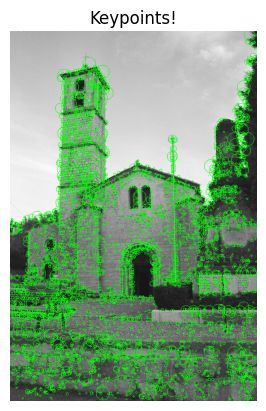

In [72]:
def draw_keypoints(img,keypoints,pyramid,sigma0,s,color=(0,255,0),radius_factor=3):
    img_rgb=cv2.cvtColor((img*255).astype(np.uint8),cv2.COLOR_GRAY2BGR)
    k=2**(1.0/s)
    for (oct_idx,scale_idx,x,y) in keypoints:
        abs_scale=sigma0*(k**scale_idx)*(2**oct_idx)
        radius=int(abs_scale*radius_factor)
        orig_x=x*(2**oct_idx)
        orig_y=y*(2**oct_idx)
        cv2.circle(img_rgb,(int(orig_x),int(orig_y)),radius,color,1)
    return img_rgb


img_with_kps=draw_keypoints(img1f,kps1,pyramid1,sigma0,s)
plt.imshow(cv2.cvtColor(img_with_kps,cv2.COLOR_BGR2RGB))
plt.title('Keypoints!')
plt.axis('off')
plt.show()


## Task 2: Compute Descriptors for Image 1

In [73]:
def compute_gradient_orientation(patch):
    gx=np.zeros_like(patch)
    gy=np.zeros_like(patch)
    gx[:,1:-1]=patch[:,2:]-patch[:,:-2]
    gy[1:-1,:]=patch[2:,:]-patch[:-2,:]
    magnitude=np.sqrt(gx**2+gy**2)
    orientation=np.arctan2(gy,gx)*180/np.pi
    orientation[orientation<0]+=360
    return magnitude,orientation


def compute_descriptor(keypoints,pyramid,s,sigma0,patch_size=16,num_bins=8):
    desc_list=[]
    valid_kps=[]
    bin_width=360/num_bins
    bins=np.arange(0,360,bin_width)+bin_width/2

    for (oct_idx,scale_idx,x,y,_) in keypoints:
        img=pyramid[oct_idx][scale_idx]
        half=patch_size//2
        if x<half or x>=img.shape[1]-half or y<half or y>=img.shape[0]-half:
            continue

        patch=img[y-half:y+half,x-half:x+half]
        mag,ori=compute_gradient_orientation(patch)

        cell_size=patch_size//4
        descriptor=[]
        for cell_i in range(4):
            for cell_j in range(4):
                cell_mag=mag[cell_i*cell_size:(cell_i+1)*cell_size,
                             cell_j*cell_size:(cell_j+1)*cell_size]
                cell_ori=ori[cell_i*cell_size:(cell_i+1)*cell_size,
                             cell_j*cell_size:(cell_j+1)*cell_size]
                hist,_=np.histogram(cell_ori,bins=num_bins,range=(0,360),weights=cell_mag)
                descriptor.extend(hist)

        descriptor=np.array(descriptor,dtype=np.float32)
        norm=np.linalg.norm(descriptor)
        if norm>0:
            descriptor/=norm
        else:
            continue
        desc_list.append(descriptor)
        valid_kps.append((oct_idx,scale_idx,x,y))

    return desc_list,valid_kps


desc1,valid_kps1=compute_descriptor(keypoints_raw1,pyramid1,s,sigma0)
print(f"Computed {len(desc1)} descriptors for image 1.")

Computed 5043 descriptors for image 1.


Visualize Example Descriptors

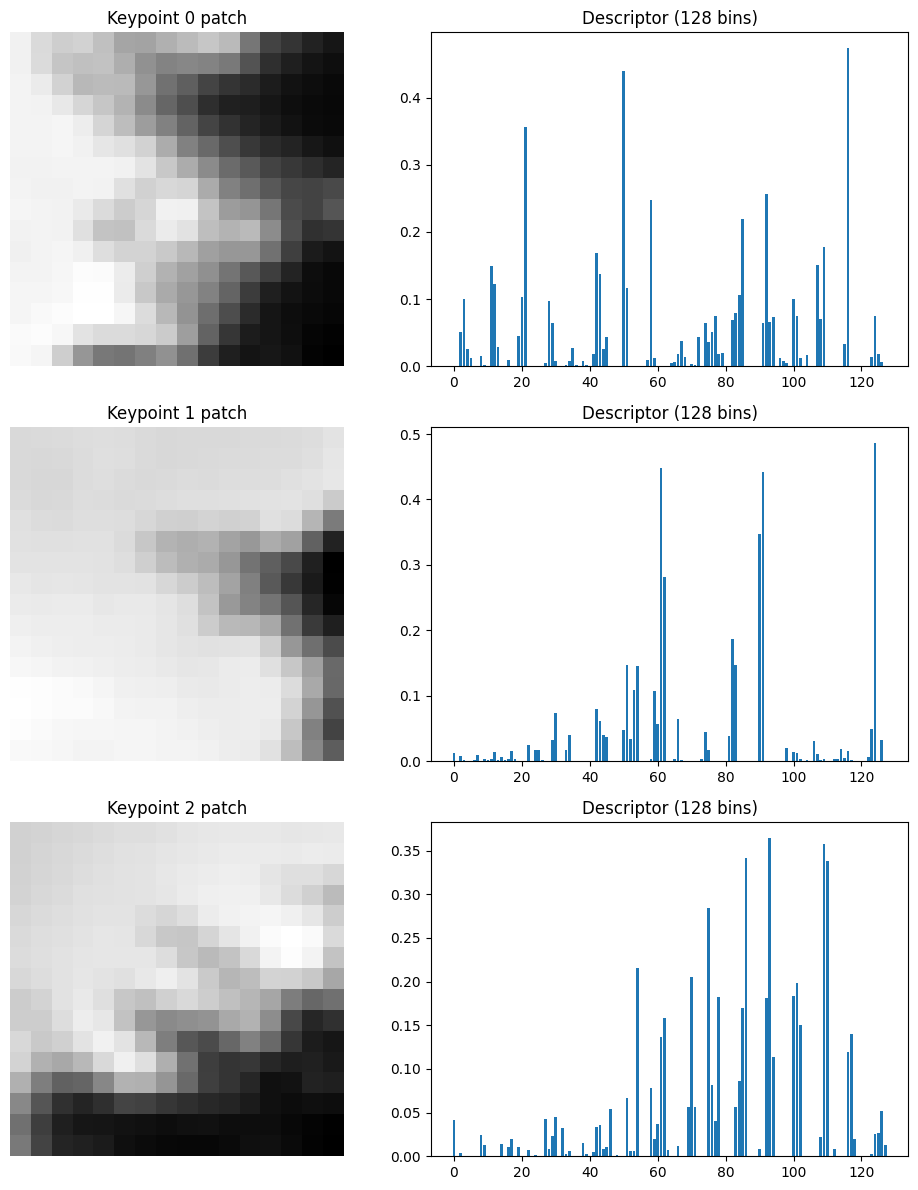

In [66]:
num_examples=min(3,len(valid_kps1))
if num_examples==0:
    print('No valid keypoints to visualize.')
else:
    fig,axes=plt.subplots(num_examples,2,figsize=(10,4*num_examples))
    if num_examples==1:
        axes=[axes]
    for idx in range(num_examples):
        kp=valid_kps1[idx]
        oct_idx,scale_idx,x,y=kp
        img=pyramid1[oct_idx][scale_idx]
        half=8
        patch=img[y-half:y+half,x-half:x+half]
        mag,ori=compute_gradient_orientation(patch)
        axes[idx][0].imshow(patch,cmap='gray')
        axes[idx][0].set_title(f'Keypoint {idx} patch')
        axes[idx][0].axis('off')
        desc=desc1[idx]
        axes[idx][1].bar(range(128),desc)
        axes[idx][1].set_title('Descriptor (128 bins)')
    plt.tight_layout()
    plt.show()

## Task 3: Process Image 2 and Match Descriptors

In [67]:
def match_descriptors(desc1,desc2,ratio_thresh=0.75):
    matches=[]
    desc1=np.array(desc1)
    desc2=np.array(desc2)
    if desc2.size==0:
        return matches
    for i,d1 in enumerate(desc1):
        dists=np.linalg.norm(desc2-d1,axis=1)
        if dists.shape[0]<2:
            continue
        idx_sorted=np.argsort(dists)
        d1_dist=dists[idx_sorted[0]]
        d2_dist=dists[idx_sorted[1]]
        if d1_dist<ratio_thresh*d2_dist:
            matches.append((i,idx_sorted[0]))
    return matches


pyramid2=build_gaussian_pyramid(img2f,s,sigma0,octaves)
dog_pyramid2=compute_dog(pyramid2)
keypoints_raw2=detect_keypoints(dog_pyramid2,s,threshold)
kps2=[(oct,sc,x,y) for (oct,sc,x,y,val) in keypoints_raw2]
print(f"Detected {len(kps2)} keypoints in image 2.")
desc2,valid_kps2=compute_descriptor(keypoints_raw2,pyramid2,s,sigma0)
print(f"Computed {len(desc2)} descriptors for image 2.")
if len(desc1)==0 or len(desc2)==0:
    print('No descriptors to match; skipping matching step.')
    matches=[]
else:
    matches=match_descriptors(desc1,desc2,ratio_thresh=0.75)
    print(f"Found {len(matches)} matches.")

Detected 4497 keypoints in image 2.
Computed 4335 descriptors for image 2.
Found 815 matches.


 Visualising a Fraction of matches across the images

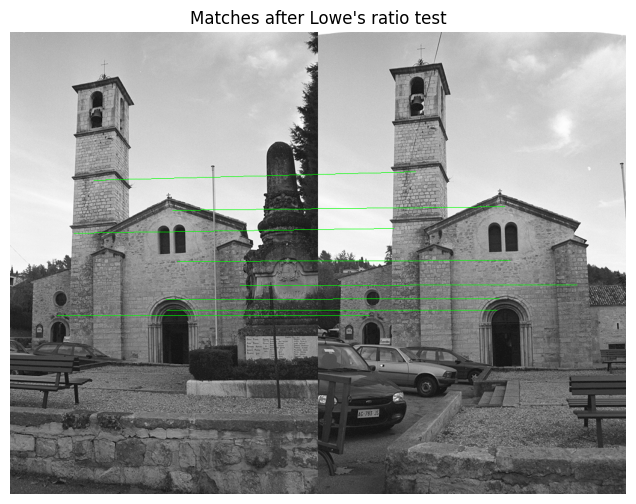

In [74]:
h1,w1=img1.shape
h2,w2=img2.shape
vis=np.zeros((max(h1,h2),w1+w2,3),dtype=np.uint8)
vis[:h1,:w1]=cv2.cvtColor(img1,cv2.COLOR_GRAY2BGR)
vis[:h2,w1:w1+w2]=cv2.cvtColor(img2,cv2.COLOR_GRAY2BGR)
match_fraction=0.01
if len(matches)>0:
    n_keep=max(1,int(len(matches)*match_fraction))
    rng=np.random.default_rng(1)
    idxs=rng.choice(len(matches),size=n_keep,replace=False)
    matches_to_draw=[matches[i] for i in idxs]
else:
    matches_to_draw=[]
for i,j in matches_to_draw:
    oct1,sc1,x1,y1=valid_kps1[i]
    oct2,sc2,x2,y2=valid_kps2[j]
    orig_x1=int(x1*(2**oct1))
    orig_y1=int(y1*(2**oct1))
    orig_x2=int(x2*(2**oct2))+w1
    orig_y2=int(y2*(2**oct2))
    cv2.line(vis,(orig_x1,orig_y1),(orig_x2,orig_y2),(0,255,0),1)
plt.figure(figsize=(12,6))
plt.imshow(vis)
plt.title('Matches after Lowe\'s ratio test')
plt.axis('off')
plt.show()

Wow, it works!!

## Task 4: Effect of Scales per Octave

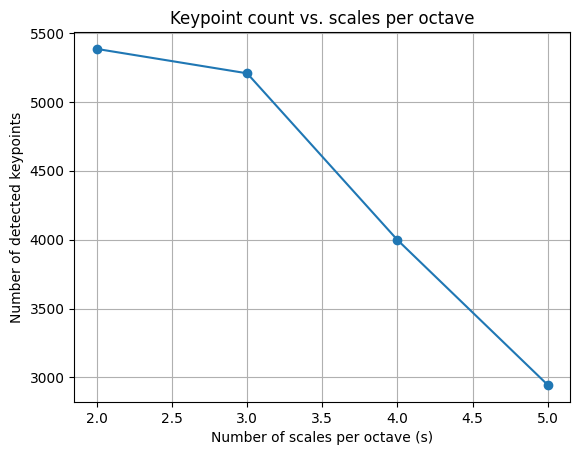

In [76]:
s_values=[2,3,4,5]
keypoint_counts=[]
for s_test in s_values:
    pyr=build_gaussian_pyramid(img1f,s_test,sigma0,octaves)
    dog=compute_dog(pyr)
    kps_raw=detect_keypoints(dog,s_test,threshold)
    keypoint_counts.append(len(kps_raw))

plt.figure()
plt.plot(s_values,keypoint_counts,marker='o')
plt.xlabel('Number of scales per octave (s)')
plt.ylabel('Number of detected keypoints')
plt.title('Keypoint count vs. scales per octave')
plt.grid(True)
plt.show()

The keypoints are decreasing with increase in scales

## Task 5: Discussion and Analysis
### 1. Scale Invariance
SIFT achieves scale invariance by constructing a scale-space pyramid (Gaussian blurring at multiple scales and octaves) and detecting local extrema in the Difference-of-Gaussians (DoG) across that space. The keypoint’s scale (octave and level) is recorded and used to normalise the descriptor region (the patch is extracted from the corresponding scale level). During matching, two keypoints with different absolute scales can correspond because their descriptors are scale‑normalised. The scale‑space representation and the scale‑adaptive descriptor are the essential components.

### 2. Rotation Invariance Problem
Our implementation computes gradient orientations relative to the image axes. If the image is rotated, all gradient orientations rotate by the same amount, causing the entire orientation histogram to shift. Consequently, the descriptor changes drastically and matching fails. To achieve rotation invariance, SIFT assigns a **dominant orientation** to each keypoint based on a local orientation histogram, then rotates the descriptor region to align with that orientation

### 3. Illumination Invariance
Unit‑length normalisation makes the descriptor invariant to multiplicative illumination changes (global contrast scaling) but does not handle non‑linear or local variations. The additional step used in SIFT, **clipping** which after normalisation, each element of the descriptor is limited to a maximum value and the vector is re‑normalised. This clipping then reduces the influence of large gradient magnitudes caused by specular highlights or strong local contrast, improving robustness to a wider range of lighting conditions.

(Resource for clipping taken from Google search)